In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

In [3]:
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
y_test  = pd.read_csv('../data/y_test.csv').values.ravel()

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Klase u treningu: {dict(zip(*np.unique(y_train, return_counts=True)))}')

X_train: (454902, 30)
X_test:  (56962, 30)
Klase u treningu: {np.int64(0): np.int64(227451), np.int64(1): np.int64(227451)}


In [4]:
baseline = MLPClassifier(hidden_layer_sizes=(64,32,16), activation='relu', learning_rate_init=0.001, max_iter = 50, random_state=42, verbose = True)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
y_prob_base = baseline.predict_proba(X_test)[:,1]

baseline_f1 =  f1_score(y_test, y_pred_base)
baseline_auc = roc_auc_score(y_test, y_pred_base)

print('BASELINE MODEL')
print(f'F1 Score (fraud): {baseline_f1:.4f}')
print(f'AUC-ROC:          {baseline_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['Legitimna', 'Prevara']))

Iteration 1, loss = 0.03023209
Iteration 2, loss = 0.00450010
Iteration 3, loss = 0.00313942
Iteration 4, loss = 0.00241271
Iteration 5, loss = 0.00220622
Iteration 6, loss = 0.00198747
Iteration 7, loss = 0.00163315
Iteration 8, loss = 0.00137735
Iteration 9, loss = 0.00153837
Iteration 10, loss = 0.00111471
Iteration 11, loss = 0.00146227
Iteration 12, loss = 0.00104704
Iteration 13, loss = 0.00107094
Iteration 14, loss = 0.00104553
Iteration 15, loss = 0.00086735
Iteration 16, loss = 0.00098410
Iteration 17, loss = 0.00081488
Iteration 18, loss = 0.00077437
Iteration 19, loss = 0.00091476
Iteration 20, loss = 0.00067000
Iteration 21, loss = 0.00061598
Iteration 22, loss = 0.00071118
Iteration 23, loss = 0.00078071
Iteration 24, loss = 0.00051104
Iteration 25, loss = 0.00062460
Iteration 26, loss = 0.00068995
Iteration 27, loss = 0.00050787
Iteration 28, loss = 0.00063795
Iteration 29, loss = 0.00057209
Iteration 30, loss = 0.00054452
Iteration 31, loss = 0.00068145
Iteration 32, los

In [5]:
param_grid = {
    'hidden_layer_sizes': [(32, 16), (64, 32), (64, 32, 16), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.0001]
}

results = []
kombinacije = [
    (h, a, lr)
    for h in param_grid['hidden_layer_sizes']
    for a in param_grid['activation']
    for lr in param_grid['learning_rate_init']
]

print(f'Ukupno kombinacija: {len(kombinacije)}')
print('Trening u toku...\n')

for i, (hidden, activation, lr) in enumerate(kombinacije):
    model = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        learning_rate_init=lr,
        max_iter=50,
        random_state=42,
        verbose=False
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'hidden_layer_sizes': str(hidden),
        'activation': activation,
        'learning_rate_init': lr,
        'f1': round(f1, 4),
        'auc': round(auc, 4)
    })
    print(f'[{i+1}/{len(kombinacije)}] {hidden} | {activation} | lr={lr} => F1={f1:.4f} | AUC={auc:.4f}')

print('\nGotovo!')

Ukupno kombinacija: 24
Trening u toku...

[1/24] (32, 16) | relu | lr=0.001 => F1=0.7080 | AUC=0.9729
[2/24] (32, 16) | relu | lr=0.01 => F1=0.7477 | AUC=0.9748
[3/24] (32, 16) | relu | lr=0.0001 => F1=0.7013 | AUC=0.9721
[4/24] (32, 16) | tanh | lr=0.001 => F1=0.7265 | AUC=0.9636
[5/24] (32, 16) | tanh | lr=0.01 => F1=0.5668 | AUC=0.9803
[6/24] (32, 16) | tanh | lr=0.0001 => F1=0.6385 | AUC=0.9656
[7/24] (64, 32) | relu | lr=0.001 => F1=0.7979 | AUC=0.9680
[8/24] (64, 32) | relu | lr=0.01 => F1=0.7137 | AUC=0.9739
[9/24] (64, 32) | relu | lr=0.0001 => F1=0.7339 | AUC=0.9674
[10/24] (64, 32) | tanh | lr=0.001 => F1=0.7465 | AUC=0.9549
[11/24] (64, 32) | tanh | lr=0.01 => F1=0.6170 | AUC=0.9588
[12/24] (64, 32) | tanh | lr=0.0001 => F1=0.6639 | AUC=0.9584
[13/24] (64, 32, 16) | relu | lr=0.001 => F1=0.7706 | AUC=0.9640
[14/24] (64, 32, 16) | relu | lr=0.01 => F1=0.7273 | AUC=0.9666
[15/24] (64, 32, 16) | relu | lr=0.0001 => F1=0.7714 | AUC=0.9669
[16/24] (64, 32, 16) | tanh | lr=0.001 =

In [6]:
df_results = pd.DataFrame(results).sort_values('f1', ascending=False)

print('=== TOP 5 KOMBINACIJA (po F1) ===')
print(df_results.head(5).to_string(index=False))
print()
print(f'Baseline F1:       {baseline_f1:.4f}')
print(f'Najbolji model F1: {df_results.iloc[0]["f1"]:.4f}')
print(f'Poboljsanje:       +{df_results.iloc[0]["f1"] - baseline_f1:.4f}')

=== TOP 5 KOMBINACIJA (po F1) ===
hidden_layer_sizes activation  learning_rate_init     f1    auc
     (128, 64, 32)       relu              0.0010 0.8122 0.9680
      (64, 32, 16)       tanh              0.0010 0.7980 0.9544
          (64, 32)       relu              0.0010 0.7979 0.9680
     (128, 64, 32)       tanh              0.0010 0.7943 0.9532
     (128, 64, 32)       relu              0.0001 0.7767 0.9710

Baseline F1:       0.7706
Najbolji model F1: 0.8122
Poboljsanje:       +0.0416


In [7]:
best_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=50,
    random_state=42,
    verbose=False
)

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print('NAJBOLJI MODEL')
print(classification_report(y_test, y_pred_best, target_names=['Legitimna', 'Prevara']))

=== NAJBOLJI MODEL ===
              precision    recall  f1-score   support

   Legitimna       1.00      1.00      1.00     56864
     Prevara       0.81      0.82      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



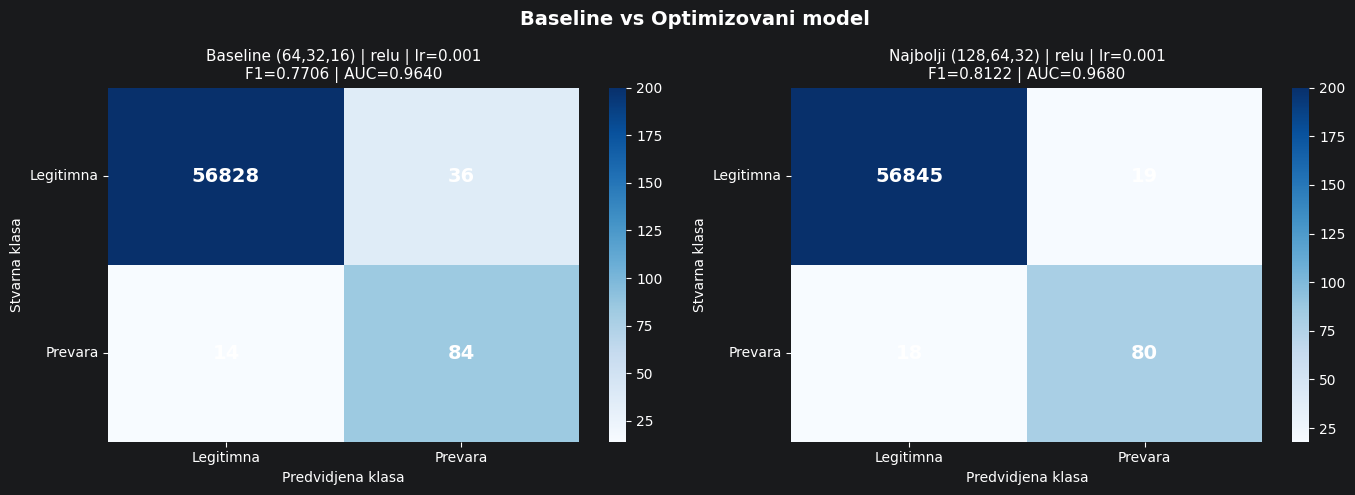

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, y_prob, title in zip(
    axes,
    [y_pred_base, y_pred_best],
    [y_prob_base, y_prob_best],
    ['Baseline (64,32,16) | relu | lr=0.001', 'Najbolji (128,64,32) | relu | lr=0.001']
):
    cm = confusion_matrix(y_test, y_pred)
    sb.heatmap(cm, annot=False, cmap='Blues', ax=ax,
               xticklabels=['Legitimna', 'Prevara'],
               yticklabels=['Legitimna', 'Prevara'],
               cbar=True, vmax=200)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]),
                    ha='center', va='center',
                    color='white', fontsize=14, fontweight='bold')
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ax.set_title(f'{title}\nF1={f1:.4f} | AUC={auc:.4f}', fontsize=11)
    ax.set_ylabel('Stvarna klasa')
    ax.set_xlabel('Predvidjena klasa')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.suptitle('Baseline vs Optimizovani model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

=== FINALNO POREĐENJE ===
                   Model Activation  Learning Rate  Precision (fraud)  Recall (fraud)  F1 (fraud)  AUC-ROC
     Baseline (64,32,16)       relu          0.001               0.70            0.86    0.770642 0.928255
Optimizovani (128,64,32)       relu          0.001               0.81            0.82    0.812183 0.967991


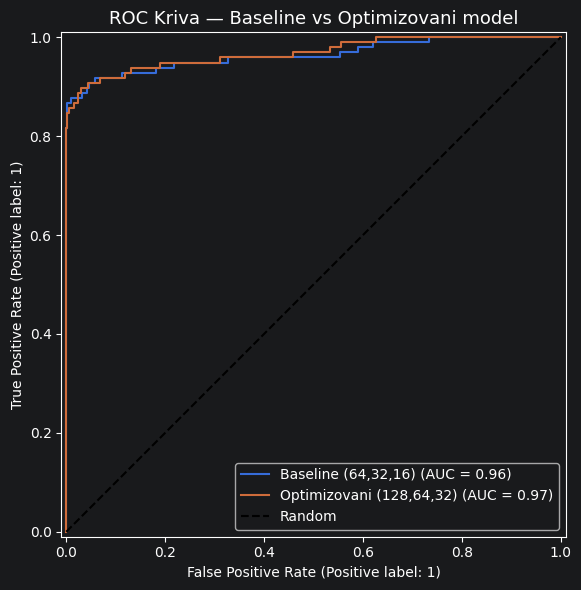

In [9]:
summary = pd.DataFrame({
    'Model': ['Baseline (64,32,16)', 'Optimizovani (128,64,32)'],
    'Activation': ['relu', 'relu'],
    'Learning Rate': [0.001, 0.001],
    'Precision (fraud)': [0.70, 0.81],
    'Recall (fraud)': [0.86, 0.82],
    'F1 (fraud)': [baseline_f1, f1_score(y_test, y_pred_best)],
    'AUC-ROC': [baseline_auc, roc_auc_score(y_test, y_prob_best)]
})

print('FINALNO POREĐENJE')
print(summary.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_base, ax=ax, name='Baseline (64,32,16)')
RocCurveDisplay.from_predictions(y_test, y_prob_best, ax=ax, name='Optimizovani (128,64,32)')
ax.set_title('ROC Kriva — Baseline vs Optimizovani model', fontsize=13)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
plt.legend()
plt.tight_layout()
plt.show()
